# Module `algorithms/visualization.py`

`plot_solution` affiche une solution VRP avec :

- le graphe residuel (aretes autres que `FORBIDDEN`) en gris fin, en fond ;
- les sous-tournees colorees, avec fleches de sens de parcours ;
- le depot en fonce, les clients en bleu clair, chaque noeud annote.

`save_solution_plot` ecrit la figure dans `DEFAULT_IMAGE_DIR = algorithms/image/` avec un index auto-incremente. Le dossier est dans `.gitignore` : **ne jamais commiter de PNG**.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent.parent / "src"))

import matplotlib.pyplot as plt

from cesipath import GraphGenerationConfig, GraphGenerator
from cesipath.algorithms import grasp, plot_solution, save_solution_plot
from cesipath.solver_input import build_static_solver_input


## 1. Tracer une solution


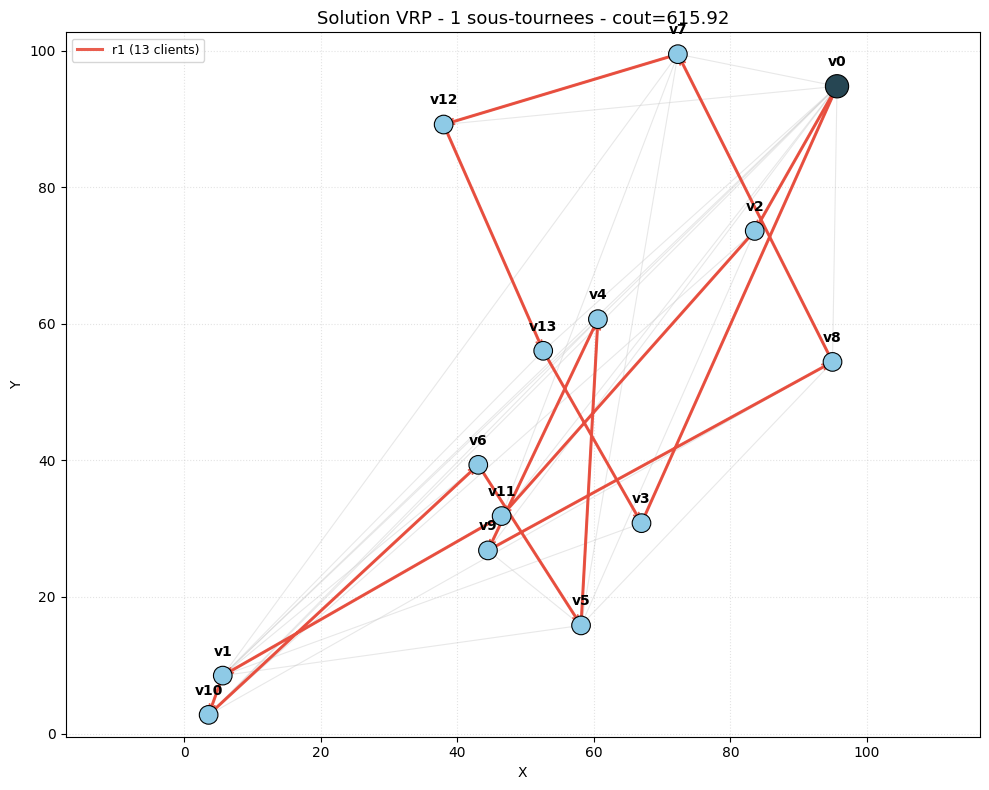

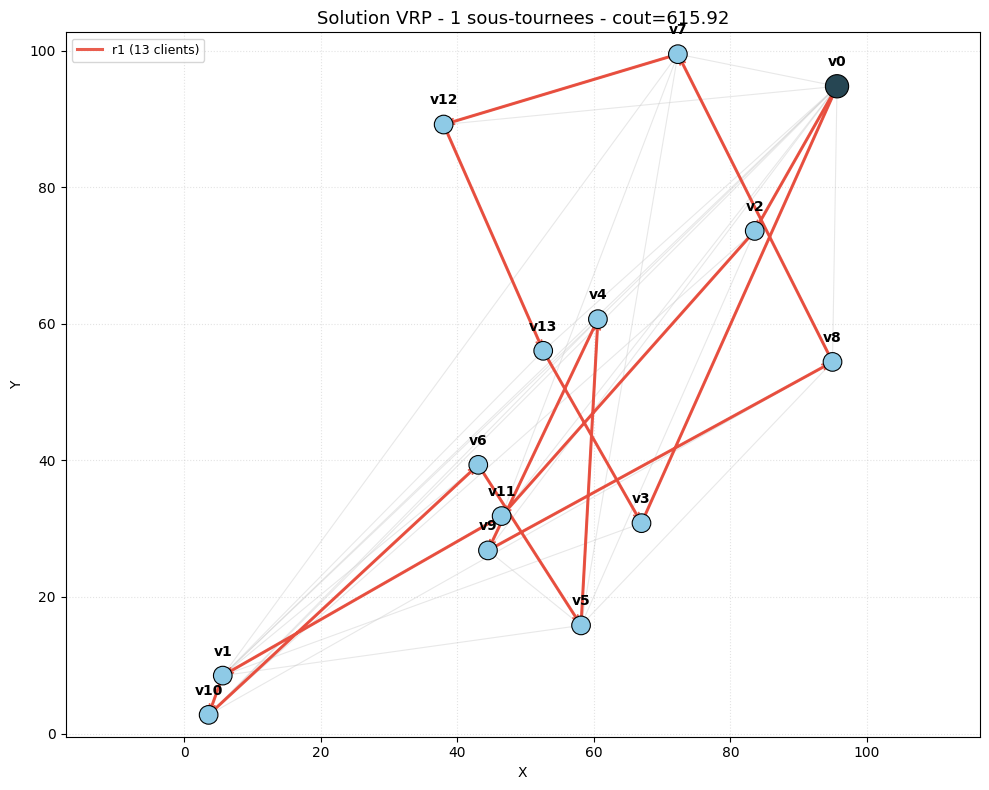

In [2]:
cfg = GraphGenerationConfig(node_count=14, seed=2)
instance = GraphGenerator(cfg).generate()
si = build_static_solver_input(instance)

sol = grasp(si, max_iterations=20, rcl_alpha=0.3, seed=0)

fig = plot_solution(instance, sol)
fig


## 2. Options courantes

- `show_residual=False` : desactive l'affichage du graphe residuel (utile si l'on veut isoler les routes).
- `title` : titre personnalise (sinon "Solution VRP - N sous-tournees - cout=X").
- `ax` : passer un axe matplotlib existant pour composer plusieurs sous-figures.


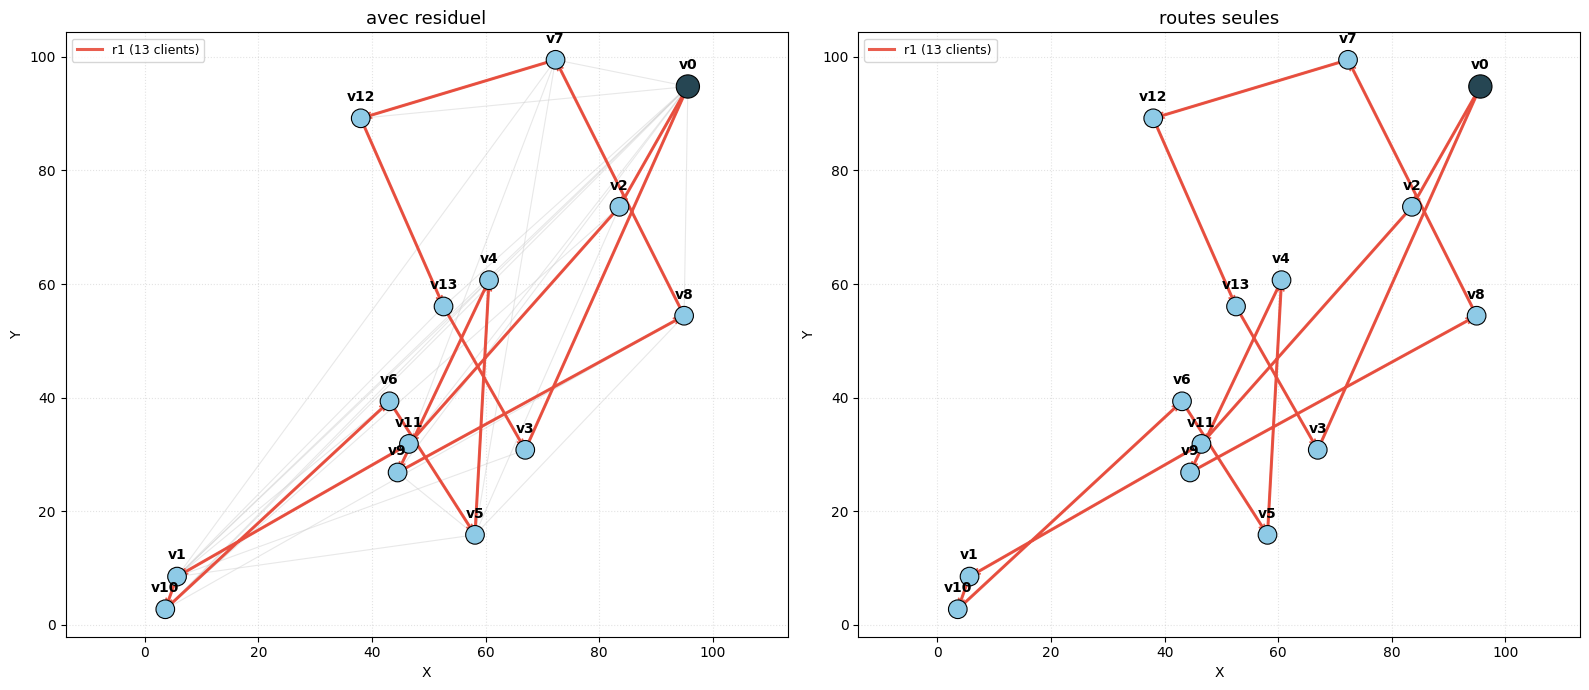

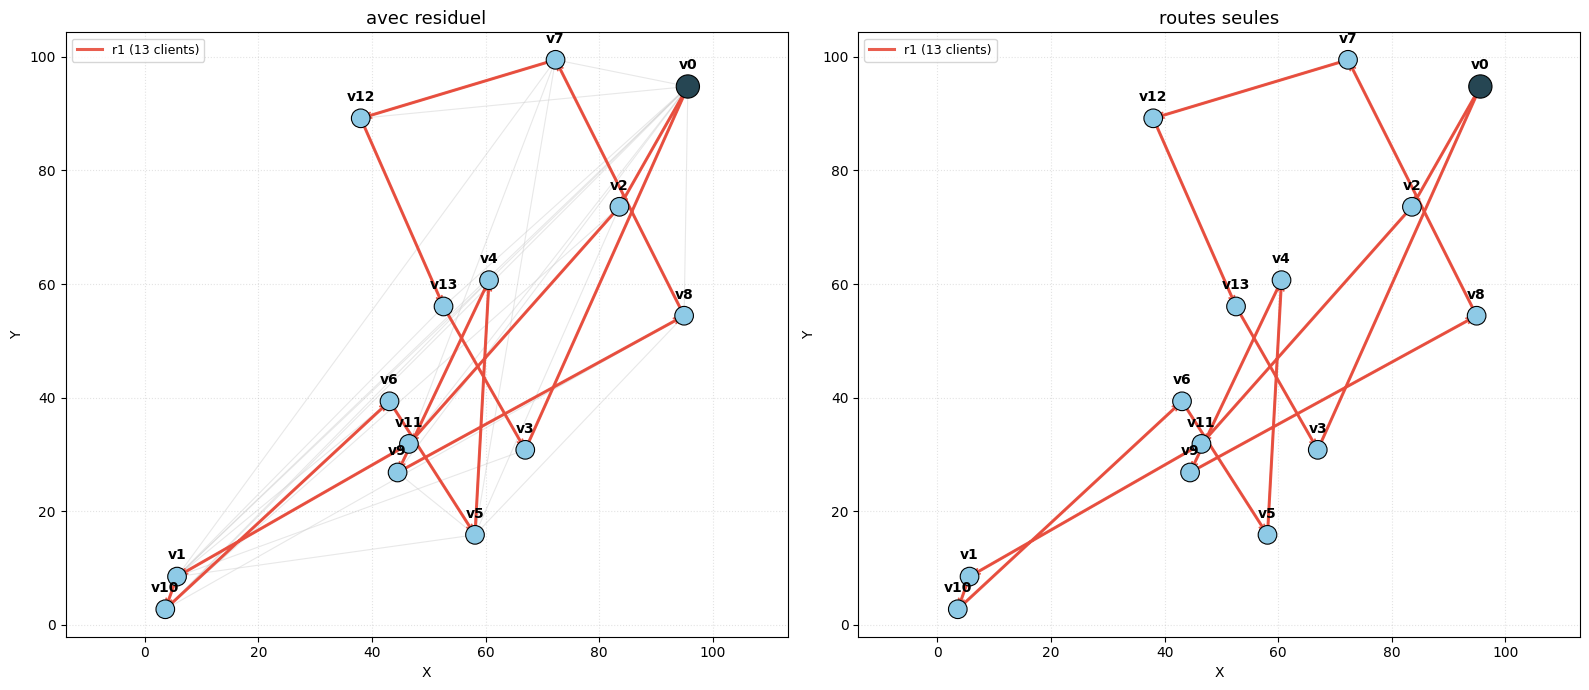

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_solution(instance, sol, ax=axes[0], show_residual=True,  title="avec residuel")
plot_solution(instance, sol, ax=axes[1], show_residual=False, title="routes seules")
fig.tight_layout()
fig


## 3. Sauvegarde avec index auto-incremente

`save_solution_plot` cree le dossier cible si besoin, puis choisit le plus petit `n >= 1` tel que `<prefix>_<n>.png` n'existe pas dans le dossier cible. Le compteur est propre au prefixe : `save_solution_plot` (`png_result`), `save_benchmark_figures` (`benchmark_*`) et `save_dynamic_benchmark_figures` (`dynamic_*`) ont chacun leur propre suite d'index.

Par defaut `prefix="png_result"` et `directory=DEFAULT_IMAGE_DIR`. Les figures se retrouvent donc dans `src/cesipath/algorithms/image/png_result_<n>.png`.


In [4]:
# Demonstration : on ecrit dans /tmp pour ne pas polluer le repo
from pathlib import Path

target = Path("/tmp/cesipath_viz_demo")
path = save_solution_plot(fig, directory=target, prefix="demo")
print("ecrit :", path)
# Appel suivant -> incremente l'index
path2 = save_solution_plot(fig, directory=target, prefix="demo")
print("ecrit :", path2)


ecrit : /tmp/cesipath_viz_demo/demo_3.png


ecrit : /tmp/cesipath_viz_demo/demo_4.png


## 4. Palette

`ROUTE_COLORS` contient 12 couleurs cyclees modulo le nombre de tournees. Au-dela de 12 tournees, les couleurs se repetent - en pratique peu genant puisque les instances cibles restent petites.
